# Access Log EDA

## 분석 목적

본 분석은 파싱이 완료된 Access Log 데이터를 대상으로 데이터의 기본 구조와 품질 상태를 확인하고, 이후 품질 검증에 사용할 규칙 후보를 정의하는 것을 목적으로 한다.

세부 목적은 다음과 같다.

1. 원본 로그가 파싱 과정에서 누락 없이 데이터프레임으로 변환되었는지 기본 무결성을 검증한다.
2. Timestamp의 최초·마지막 시각과 전체 수집 기간을 확인한다.
3. HTTP Method와 Status 분포를 분석하여 요청 및 응답 특성을 파악한다.
4. 주요 IP와 Path의 등장 빈도를 확인하여 반복 요청과 특이한 접근 패턴을 조사한다.
5. Referer, User-Agent, 응답 크기 등 주요 필드의 값과 결측 현황을 확인한다.
6. `EMPTY_REQUEST`와 `NON_STANDARD_REQUEST`를 별도로 추출하여 발생 원인과 특징을 조사한다.
7. 정상적으로 기록된 특이 요청과 실제 데이터 오류를 구분한다.
8. 분석 결과를 바탕으로 `VALID`, `VALID_ANOMALY`, `INVALID_DATA` 분류 기준과 Access Log 품질 규칙 후보를 작성한다.

## 분석 대상

* 데이터 종류: Apache Access Log
* 입력 파일: `data/interim/access_parsed.csv`
* 분석 파일: `notebooks/01_week1_access_eda.ipynb`

## 최종 목표

비표준 요청이나 오류 응답을 무조건 잘못된 데이터로 처리하지 않고, 로그가 정상적으로 기록되었는지와 데이터 분석에 사용할 수 있는지를 기준으로 품질을 판단한다. 이를 통해 향후 자동 품질 검증과 이상 데이터 관리에 사용할 수 있는 근거를 마련한다.
터 관리에 사용할 수 있는 근거를 마련한다.


In [2]:
# 라이브러리 및 경로 설정
from pathlib import Path
import pandas as pd

In [3]:
# access_parsed.csv 불러오기
DATA_PATH = Path(
    "../data/interim/access_parsed.csv"
).resolve()



In [4]:
# 컬럼 자료형 변환
df = pd.read_csv(
    DATA_PATH,
    encoding="utf-8-sig",
)

print(f"검증 대상: {DATA_PATH}")
print(f"전체 행 수: {len(df):,}")

검증 대상: C:\Users\seoyeon\log-dlq-pipeline\data\interim\access_parsed.csv
전체 행 수: 5,143


In [5]:
# 기본 무결성 검증
expected_columns = {
    "line_no",
    "raw_line",
    "ip",
    "ident",
    "authuser",
    "time_raw",
    "time",
    "request",
    "method",
    "path",
    "protocol",
    "status",
    "size",
    "referer",
    "agent",
    "parse_status",
    "request_type",
    "parse_note",
}

missing_columns = expected_columns - set(df.columns)
unexpected_columns = set(df.columns) - expected_columns

assert not missing_columns, (
    f"필수 컬럼이 누락되었습니다: {sorted(missing_columns)}"
)

assert df["line_no"].notna().all(), (
    "line_no에 결측치가 있습니다."
)

assert df["line_no"].is_unique, (
    "line_no가 중복되었습니다."
)

assert df["raw_line"].notna().all(), (
    "raw_line에 결측치가 있습니다."
)

assert df["parse_status"].notna().all(), (
    "parse_status에 결측치가 있습니다."
)

assert df["parse_status"].isin(
    ["SUCCESS", "PARTIAL", "FAIL"]
).all(), (
    "정의되지 않은 parse_status가 있습니다."
)

print("기본 무결성 검증 통과")
print(f"- 전체 행 수: {len(df):,}")
print(f"- 전체 컬럼 수: {len(df.columns)}")
print(f"- line_no 고유 여부: {df['line_no'].is_unique}")
print(f"- 추가 컬럼: {sorted(unexpected_columns)}")

기본 무결성 검증 통과
- 전체 행 수: 5,143
- 전체 컬럼 수: 18
- line_no 고유 여부: True
- 추가 컬럼: []


In [6]:
EXPECTED_ROW_COUNT = 5_143

assert len(df) == EXPECTED_ROW_COUNT, (
    f"예상 행 수는 {EXPECTED_ROW_COUNT:,}개지만 "
    f"실제 행 수는 {len(df):,}개입니다."
)

In [7]:
#parse_status 분포 확인
parse_status_summary = (
    df["parse_status"]
    .value_counts()
    .reindex(
        ["SUCCESS", "PARTIAL", "FAIL"],
        fill_value=0,
    )
    .rename_axis("parse_status")
    .reset_index(name="count")
)

parse_status_summary["rate_pct"] = (
    parse_status_summary["count"]
    / len(df)
    * 100
).round(2)

display(parse_status_summary)

,parse_status,count,rate_pct
0,SUCCESS,5143,100.0
1,PARTIAL,0,0.0
2,FAIL,0,0.0


### 기본 무결성 검증 결과

- 전체 Access Log는 5,143건이다.
- 예상 행 수와 실제 데이터프레임 행 수가 일치한다.
- 전체 5,143건이 `SUCCESS`로 파싱되었다.
- `PARTIAL`과 `FAIL` 데이터는 발견되지 않았다.
- 기본 무결성 검증을 통과했으므로 이후 EDA를 진행한다.

### EDA

In [10]:
# Timestamp 분석 
# Timestamp 자료형 변환
df["time"] = pd.to_datetime(
    df["time"],
    errors="coerce",
    utc=True,
).dt.tz_convert("Asia/Seoul")


# 최소, 최대, 수집 기간
start_time = df["time"].min()
end_time = df["time"].max()
collection_duration = end_time - start_time
timestamp_failure_count = df["time"].isna().sum()
active_date_count = df["time"].dt.date.nunique()


# 결과 요약
timestamp_summary = pd.DataFrame({
    "항목": [
        "전체 로그 수",
        "최초 Timestamp",
        "마지막 Timestamp",
        "전체 수집 기간",
        "Timestamp 변환 실패",
        "로그가 존재하는 날짜 수",
    ],
    "결과": [
        len(df),
        start_time,
        end_time,
        collection_duration,
        timestamp_failure_count,
        active_date_count,
    ],
})

# 출력
display(timestamp_summary)

,항목,결과
0,전체 로그 수,5143
1,최초 Timestamp,2025-06-12 13:35:37+09:00
2,마지막 Timestamp,2025-07-28 16:11:16+09:00
3,전체 수집 기간,46 days 02:35:39
4,Timestamp 변환 실패,0
5,로그가 존재하는 날짜 수,44


In [11]:
# 날짜별 로그 수
daily_requests = (
    df.dropna(subset=["time"])
    .assign(date=lambda data: data["time"].dt.date)
    .groupby("date")
    .size()
    .reset_index(name="count")
)

display(daily_requests)

,date,count
0,2025-06-12,176
1,2025-06-16,124
2,2025-06-17,132
3,2025-06-18,68
4,2025-06-19,88
5,2025-06-20,57
6,2025-06-21,119
7,2025-06-22,117
8,2025-06-23,453
9,2025-06-24,92


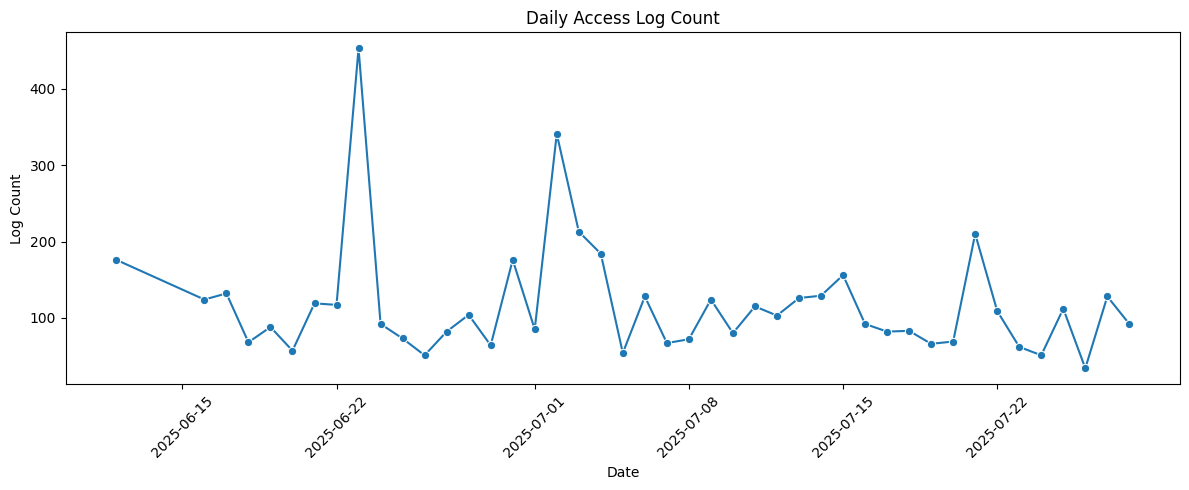

In [12]:
# 그래프로 출력
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 5))

sns.lineplot(
    data=daily_requests,
    x="date",
    y="count",
    marker="o",
)

plt.title("Daily Access Log Count")
plt.xlabel("Date")
plt.ylabel("Log Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Method 분포 (STANDARD_HTTP 요청만 분석)

# STANDARD_HTTP 요청만 뽑아내기
standard_requests = df.loc[
    df["request_type"].eq("STANDARD_HTTP")
].copy()

# method별 건수
method_summary = (
    standard_requests["method"]
    .value_counts(dropna=False)
    .rename_axis("method")
    .reset_index(name="count")
)

# method 별 비율 확인
method_summary["rate_pct"] = (
    method_summary["count"]
    / len(standard_requests)
    * 100
).round(2)

display(method_summary)


,method,count,rate_pct
0,GET,4167,91.00
1,POST,165,3.60
2,HEAD,129,2.82
3,PRI,79,1.73
4,OPTIONS,19,0.41
5,CONNECT,10,0.22
6,PUT,10,0.22


In [14]:
# status 분포
# status별 갯수 확인
status_summary = (
    df["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

# 비율 확인
status_summary["rate_pct"] = (
    status_summary["count"]
    / len(df)
    * 100
).round(2)

display(status_summary)

,status,count,rate_pct
0,404,3205,62.32
1,200,1106,21.50
2,400,632,12.29
3,304,74,1.44
4,408,45,0.87
5,503,45,0.87
6,405,21,0.41
7,403,6,0.12
8,302,6,0.12
9,502,3,0.06


In [15]:
# status 그룹 확인
# 앞번호로 그룹 나누기
def classify_status_group(status):
    if pd.isna(status):
        return "MISSING"

    return f"{int(status) // 100}xx"


df["status_group"] = (
    df["status"]
    .apply(classify_status_group)
)


status_group_summary = (
    df["status_group"]
    .value_counts(dropna=False)
    .rename_axis("status_group")
    .reset_index(name="count")
)

display(status_group_summary)

,status_group,count
0,4xx,3909
1,2xx,1106
2,3xx,80
3,5xx,48


| 그룹        | 의미          |
| --------- | ----------- |
| `2xx`     | 정상 처리       |
| `3xx`     | 리다이렉션       |
| `4xx`     | 클라이언트 요청 오류 |
| `5xx`     | 서버 오류       |
| `MISSING` | Status 누락   |


In [17]:
# IP 분석
# 접근한 IP 개수
unique_ip_count = df["ip"].nunique(dropna=True)

print(f"Unique IP 수: {unique_ip_count:,}")


# 많이 접근한 ip 상위 20개 출력
top_ips = (
    df["ip"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("ip")
    .reset_index(name="count")
)

display(top_ips)

Unique IP 수: 1,084


,ip,count
0,210.110.68.35,138
1,36.95.95.178,127
2,177.87.45.11,127
3,206.189.206.126,127
4,167.71.239.135,127
5,157.230.228.213,127
6,192.99.152.209,127
7,103.105.196.254,127
8,210.110.64.41,110
9,149.50.96.5,110


In [18]:
# Path 분석
# 접근 path 갯수
unique_path_count = (
    standard_requests["path"]
    .nunique(dropna=True)
)

print(f"Unique Path 수: {unique_path_count:,}")


# 상위 20개 출력
top_paths = (
    standard_requests["path"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("path")
    .reset_index(name="count")
)

display(top_paths)

Unique Path 수: 450


,path,count
0,/,963
1,/favicon.ico,267
2,/.env,136
3,/.git/config,99
4,*,79
5,/systembc/password.php,57
6,/t4,57
7,/form.html,57
8,/password.php,57
9,/1.php,57


In [19]:
# Path와 Status 함께 보기
path_status_summary = (
    standard_requests
    .groupby(
        ["path", "status"],
        dropna=False,
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False,
    )
)

display(path_status_summary.head(30))

,path,status,count
1,/,200,912
177,/favicon.ico,404,250
14,/.env,404,136
22,/.git/config,404,99
0,*,400,79
179,/form.html,404,57
27,/1.php,404,57
401,/t4,404,57
180,/geoip/,404,57
407,/upl.php,404,57


In [20]:
# 결측값 분석
missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": [
        df[column].isna().sum()
        for column in df.columns
    ],
})

missing_summary["missing_rate_pct"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
).round(2)

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False,
)

display(missing_summary)

,column,missing_count,missing_rate_pct
17,parse_note,5143,100.00
3,ident,5143,100.00
4,authuser,5143,100.00
13,referer,4731,91.99
14,agent,1269,24.67
9,path,564,10.97
8,method,564,10.97
10,protocol,564,10.97
12,size,267,5.19
16,request_type,0,0.00


In [21]:
# Referer 등장 빈도
referer_summary = (
    df["referer"]
    .fillna("(MISSING)")
    .value_counts()
    .head(20)
    .rename_axis("referer")
    .reset_index(name="count")
)

display(referer_summary)

,referer,count
0,(MISSING),4731
1,http://210.110.104.16/notice,53
2,http://dse.swu.ac.kr/,53
3,http://114.70.38.81:80/admin/login.asp,40
4,http://114.70.38.81/,40
5,http://dse.swu.ac.kr/board,37
6,http://210.110.104.16/,34
7,http://210.110.104.16/board,33
8,http://dse.swu.ac.kr/write,22
9,http://dse.swu.ac.kr/notice,21


In [22]:
# User-Agent 등장 빈도
agent_summary = (
    df["agent"]
    .fillna("(MISSING)")
    .value_counts()
    .head(20)
    .rename_axis("agent")
    .reset_index(name="count")
)

display(agent_summary)

,agent,count
0,(MISSING),1269
1,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,889
2,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,305
3,Custom-AsyncHttpClient,270
4,Mozilla/5.0; Keydrop.io/1.0(onlyscans.com/about);,168
5,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,165
6,Mozilla/5.0 (compatible; CensysInspect/1.1; +h...,160
7,Mozilla/5.0,147
8,Mozilla/5.0 zgrab/0.x,143
9,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,125


In [23]:
# Size 기초 통계
display(df["size"].describe())

# Size 등장 빈도
size_frequency = (
    df["size"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("size")
    .reset_index(name="count")
)

display(size_frequency)

count     4876.000000
mean       960.725800
std       1504.514247
min        178.000000
25%        232.000000
50%        232.000000
75%        232.000000
max      15443.000000
Name: size, dtype: float64

,size,count
0,232.0,3068
1,3809.0,896
2,226.0,632
3,NaN,267
4,299.0,45
5,501.0,27
6,1761.0,23
7,1904.0,21
8,178.0,21
9,1233.0,18


In [24]:
# Request 유형 분석
request_type_summary = (
    df["request_type"]
    .value_counts(dropna=False)
    .rename_axis("request_type")
    .reset_index(name="count")
)

# 비율 확인
request_type_summary["rate_pct"] = (
    request_type_summary["count"]
    / len(df)
    * 100
).round(2)

display(request_type_summary)

,request_type,count,rate_pct
0,STANDARD_HTTP,4579,89.03
1,NON_STANDARD_REQUEST,519,10.09
2,EMPTY_REQUEST,45,0.87


In [25]:
# EMPTY_REQUEST 조사
empty_requests = df.loc[
    df["request_type"].eq("EMPTY_REQUEST")
].copy()

print(f"EMPTY_REQUEST 건수: {len(empty_requests):,}")

display(
    empty_requests[
        [
            "line_no",
            "ip",
            "time",
            "request",
            "status",
            "raw_line",
        ]
    ].head(20)
)

EMPTY_REQUEST 건수: 45


,line_no,ip,time,request,status,raw_line
4,5,210.110.68.35,2025-06-12 13:36:26+09:00,-,408,210.110.68.35 - - [12/Jun/2025:13:36:26 +0900]...
10,11,210.110.68.35,2025-06-12 16:46:29+09:00,-,408,210.110.68.35 - - [12/Jun/2025:16:46:29 +0900]...
12,13,210.110.68.35,2025-06-12 16:49:34+09:00,-,408,210.110.68.35 - - [12/Jun/2025:16:49:34 +0900]...
17,18,210.110.64.41,2025-06-12 16:58:03+09:00,-,408,210.110.64.41 - - [12/Jun/2025:16:58:03 +0900]...
18,19,210.110.64.41,2025-06-12 16:58:03+09:00,-,408,210.110.64.41 - - [12/Jun/2025:16:58:03 +0900]...
31,32,220.67.241.146,2025-06-12 17:18:36+09:00,-,408,220.67.241.146 - - [12/Jun/2025:17:18:36 +0900...
38,39,210.110.68.35,2025-06-12 17:41:57+09:00,-,408,210.110.68.35 - - [12/Jun/2025:17:41:57 +0900]...
60,61,220.67.241.146,2025-06-12 17:43:44+09:00,-,408,220.67.241.146 - - [12/Jun/2025:17:43:44 +0900...
61,62,210.110.64.41,2025-06-12 17:43:55+09:00,-,408,210.110.64.41 - - [12/Jun/2025:17:43:55 +0900]...
62,63,210.110.68.35,2025-06-12 17:44:16+09:00,-,408,210.110.68.35 - - [12/Jun/2025:17:44:16 +0900]...


In [26]:
# Status 분포
display(
    empty_requests["status"]
    .value_counts(dropna=False)
)

status
408    45
Name: count, dtype: int64

EMPTY_REQUEST는 현재 다 Status가 408이다.

In [28]:
# IP 형식 검증
import ipaddress


def is_valid_ip(value):
    if pd.isna(value):
        return False

    try:
        ipaddress.ip_address(str(value).strip())
        return True
    except ValueError:
        return False


df["is_valid_ip"] = (
    df["ip"]
    .apply(is_valid_ip)
)

invalid_ip_rows = df.loc[
    ~df["is_valid_ip"]
].copy()


print(f"전체 로그 수: {len(df):,}")
print(f"정상 IP: {df['is_valid_ip'].sum():,}")
print(f"IP 형식 이상: {len(invalid_ip_rows):,}")

display(
    invalid_ip_rows[
        [
            "line_no",
            "ip",
            "time",
            "request",
            "status",
            "raw_line",
        ]
    ].head(30)
)

전체 로그 수: 5,143
정상 IP: 5,143
IP 형식 이상: 0


,line_no,ip,time,request,status,raw_line


In [29]:
# IP 형식 요약표
ip_validation_summary = pd.DataFrame({
    "항목": [
        "전체 로그 수",
        "Unique IP 수",
        "정상 IP 형식",
        "IP 형식 이상",
    ],
    "건수": [
        len(df),
        df["ip"].nunique(dropna=True),
        df["is_valid_ip"].sum(),
        (~df["is_valid_ip"]).sum(),
    ],
})

display(ip_validation_summary)

,항목,건수
0,전체 로그 수,5143
1,Unique IP 수,1084
2,정상 IP 형식,5143
3,IP 형식 이상,0


In [30]:
# NON_STANDARD_REQUEST 조사
non_standard_requests = df.loc[
    df["request_type"].eq("NON_STANDARD_REQUEST")
].copy()

print(
    f"NON_STANDARD_REQUEST 건수: "
    f"{len(non_standard_requests):,}"
)

# 30개만 출력
display(
    non_standard_requests[
        [
            "line_no",
            "ip",
            "time",
            "request",
            "status",
            "raw_line",
        ]
    ].head(30)
)

NON_STANDARD_REQUEST 건수: 519


,line_no,ip,time,request,status,raw_line
285,286,91.90.126.37,2025-06-16 17:46:20+09:00,SSH-2.0-WanScannerBot,400,91.90.126.37 - - [16/Jun/2025:17:46:20 +0900] ...
286,287,91.90.126.37,2025-06-16 17:46:20+09:00,\x03,400,91.90.126.37 - - [16/Jun/2025:17:46:20 +0900] ...
287,288,91.90.126.37,2025-06-16 17:46:21+09:00,\x10\x0f,400,91.90.126.37 - - [16/Jun/2025:17:46:21 +0900] ...
288,289,91.90.126.37,2025-06-16 17:46:30+09:00,OPTIONS / RTSP/1.0,400,91.90.126.37 - - [16/Jun/2025:17:46:30 +0900] ...
289,290,91.90.126.37,2025-06-16 17:46:35+09:00,\x01,400,91.90.126.37 - - [16/Jun/2025:17:46:35 +0900] ...
291,292,34.94.93.67,2025-06-16 19:01:39+09:00,\x16\x03\x01,400,"34.94.93.67 - - [16/Jun/2025:19:01:39 +0900] ""..."
307,308,159.223.171.113,2025-06-17 01:52:54+09:00,\x16\x03\x01,400,159.223.171.113 - - [17/Jun/2025:01:52:54 +090...
308,309,159.223.171.113,2025-06-17 01:52:55+09:00,\x16\x03\x01,400,159.223.171.113 - - [17/Jun/2025:01:52:55 +090...
309,310,159.223.171.113,2025-06-17 01:52:55+09:00,\x16\x03\x01,400,159.223.171.113 - - [17/Jun/2025:01:52:55 +090...
341,342,172.236.137.159,2025-06-17 09:04:06+09:00,OPTIONS / RTSP/1.0,400,172.236.137.159 - - [17/Jun/2025:09:04:06 +090...


## Access Log 품질 규칙 후보

| Rule | 규칙명 | 분류 |
|---|---|---|
| A01 | Timestamp 변환 실패 | INVALID_DATA |
| A02 | Status 누락 | INVALID_DATA |
| A03 | 빈 Request | VALID_ANOMALY |
| A04 | 비표준 HTTP Request | VALID_ANOMALY |
| A05 | IP 형식 이상 | INVALID_DATA |
| A06 | Raw Line 누락 | INVALID_DATA |
| A07 | Line 번호 누락 | INVALID_DATA |
| A08 | Line 번호 중복 | INVALID_DATA |
| A09 | 파싱 실패 | INVALID_DATA |
| A10 | 부분 파싱 | INVALID_DATA |
| A11 | 표준 HTTP Request 누락 | INVALID_DATA |
| A12 | HTTP Method 누락 | INVALID_DATA |
| A13 | HTTP Path 누락 | INVALID_DATA |
| A14 | HTTP Protocol 누락 | INVALID_DATA |
| A15 | HTTP Status 범위 이상 | INVALID_DATA |
| A16 | Response Size 음수 | INVALID_DATA |
| A17 | Response Size 누락 | VALID_ANOMALY |
| A18 | 미정의 HTTP Method | VALID_ANOMALY |
| A19 | 비표준 HTTP Protocol | VALID_ANOMALY |
| A20 | Request 파싱 결과 불일치 | INVALID_DATA |석 불가 |

In [32]:
# Access Log 품질 규칙

# A01: Timestamp 변환 실패
df["A01"] = df["time"].isna()


# A02: Status 누락
df["A02"] = df["status"].isna()


# A03: 빈 Request
df["A03"] = (
    df["request_type"]
    .eq("EMPTY_REQUEST")
)


# A04: 비표준 HTTP Request
df["A04"] = (
    df["request_type"]
    .eq("NON_STANDARD_REQUEST")
)


# A05: IP 형식 이상
df["A05"] = ~df["is_valid_ip"]


# A06: Raw Line 누락
df["A06"] = (
    df["raw_line"].isna()
    | df["raw_line"]
      .fillna("")
      .astype(str)
      .str.strip()
      .eq("")
)


# A07: Line 번호 누락
df["A07"] = df["line_no"].isna()


# A08: Line 번호 중복
df["A08"] = (
    df["line_no"]
    .duplicated(keep=False)
)


# A09: 파싱 실패
df["A09"] = (
    df["parse_status"]
    .eq("FAIL")
)


# A10: 부분 파싱
df["A10"] = (
    df["parse_status"]
    .eq("PARTIAL")
)


# STANDARD_HTTP 여부
standard_mask = (
    df["request_type"]
    .eq("STANDARD_HTTP")
)


# A11: STANDARD_HTTP인데 Request 누락
df["A11"] = (
    standard_mask
    & df["request"].isna()
)


# A12: STANDARD_HTTP인데 Method 누락
df["A12"] = (
    standard_mask
    & df["method"].isna()
)


# A13: STANDARD_HTTP인데 Path 누락
df["A13"] = (
    standard_mask
    & df["path"].isna()
)


# A14: STANDARD_HTTP인데 Protocol 누락
df["A14"] = (
    standard_mask
    & df["protocol"].isna()
)


# A15: HTTP Status 범위 이상
df["A15"] = (
    df["status"].notna()
    & ~df["status"].between(100, 599)
)


# A16: Response Size 음수
df["A16"] = (
    df["size"].notna()
    & df["size"].lt(0)
)


# A17: Response Size 누락
df["A17"] = df["size"].isna()


# 알려진 HTTP Method
known_methods = {
    "GET",
    "POST",
    "PUT",
    "DELETE",
    "PATCH",
    "HEAD",
    "OPTIONS",
    "CONNECT",
    "TRACE",
    "PRI",
}


# A18: 미정의 HTTP Method
df["A18"] = (
    standard_mask
    & df["method"].notna()
    & ~df["method"].isin(known_methods)
)


# 알려진 HTTP Protocol
known_protocols = {
    "HTTP/0.9",
    "HTTP/1.0",
    "HTTP/1.1",
    "HTTP/2",
    "HTTP/2.0",
    "HTTP/3",
}


# A19: 비표준 HTTP Protocol
df["A19"] = (
    standard_mask
    & df["protocol"].notna()
    & ~df["protocol"].isin(known_protocols)
)


# Request 재구성
reconstructed_request = (
    df["method"].fillna("")
    + " "
    + df["path"].fillna("")
    + " "
    + df["protocol"].fillna("")
).str.strip()


# A20: Request와 파싱 결과 불일치
df["A20"] = (
    standard_mask
    & df["request"].notna()
    & (
        df["request"]
        .astype(str)
        .str.strip()
        .ne(reconstructed_request)
    )
)

In [33]:
access_quality_rules = {
    "A01": {
        "rule_name": "Timestamp 변환 실패",
        "category": "INVALID_DATA",
    },
    "A02": {
        "rule_name": "Status 누락",
        "category": "INVALID_DATA",
    },
    "A03": {
        "rule_name": "빈 Request",
        "category": "VALID_ANOMALY",
    },
    "A04": {
        "rule_name": "비표준 HTTP Request",
        "category": "VALID_ANOMALY",
    },
    "A05": {
        "rule_name": "IP 형식 이상",
        "category": "INVALID_DATA",
    },
    "A06": {
        "rule_name": "Raw Line 누락",
        "category": "INVALID_DATA",
    },
    "A07": {
        "rule_name": "Line 번호 누락",
        "category": "INVALID_DATA",
    },
    "A08": {
        "rule_name": "Line 번호 중복",
        "category": "INVALID_DATA",
    },
    "A09": {
        "rule_name": "파싱 실패",
        "category": "INVALID_DATA",
    },
    "A10": {
        "rule_name": "부분 파싱",
        "category": "INVALID_DATA",
    },
    "A11": {
        "rule_name": "표준 HTTP Request 누락",
        "category": "INVALID_DATA",
    },
    "A12": {
        "rule_name": "HTTP Method 누락",
        "category": "INVALID_DATA",
    },
    "A13": {
        "rule_name": "HTTP Path 누락",
        "category": "INVALID_DATA",
    },
    "A14": {
        "rule_name": "HTTP Protocol 누락",
        "category": "INVALID_DATA",
    },
    "A15": {
        "rule_name": "HTTP Status 범위 이상",
        "category": "INVALID_DATA",
    },
    "A16": {
        "rule_name": "Response Size 음수",
        "category": "INVALID_DATA",
    },
    "A17": {
        "rule_name": "Response Size 누락",
        "category": "VALID_ANOMALY",
    },
    "A18": {
        "rule_name": "미정의 HTTP Method",
        "category": "VALID_ANOMALY",
    },
    "A19": {
        "rule_name": "비표준 HTTP Protocol",
        "category": "VALID_ANOMALY",
    },
    "A20": {
        "rule_name": "Request 파싱 결과 불일치",
        "category": "INVALID_DATA",
    },
}

In [34]:
# 형식 검증 결과표 통합

validation_results = []

for rule_id, rule_info in access_quality_rules.items():
    count = int(df[rule_id].sum())
    rate_pct = round(count / len(df) * 100, 2)

    validation_results.append({
        "rule_id": rule_id,
        "rule_name": rule_info["rule_name"],
        "category": rule_info["category"],
        "count": count,
        "rate_pct": rate_pct,
    })


access_validation_summary = pd.DataFrame(
    validation_results
)

display(access_validation_summary)

,rule_id,rule_name,category,count,rate_pct
0,A01,Timestamp 변환 실패,INVALID_DATA,0,0.00
1,A02,Status 누락,INVALID_DATA,0,0.00
2,A03,빈 Request,VALID_ANOMALY,45,0.87
3,A04,비표준 HTTP Request,VALID_ANOMALY,519,10.09
4,A05,IP 형식 이상,INVALID_DATA,0,0.00
5,A06,Raw Line 누락,INVALID_DATA,0,0.00
6,A07,Line 번호 누락,INVALID_DATA,0,0.00
7,A08,Line 번호 중복,INVALID_DATA,0,0.00
8,A09,파싱 실패,INVALID_DATA,0,0.00
9,A10,부분 파싱,INVALID_DATA,0,0.00


In [35]:
# 행별 최종 품질 상태 분류

invalid_rules = [
    "A01",
    "A02",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09",
    "A10",
    "A11",
    "A12",
    "A13",
    "A14",
    "A15",
    "A16",
    "A20",
]


anomaly_rules = [
    "A03",
    "A04",
    "A17",
    "A18",
    "A19",
]


invalid_mask = (
    df[invalid_rules]
    .any(axis=1)
)

anomaly_mask = (
    df[anomaly_rules]
    .any(axis=1)
)


df["quality_status"] = "VALID"

df.loc[
    anomaly_mask,
    "quality_status"
] = "VALID_ANOMALY"

df.loc[
    invalid_mask,
    "quality_status"
] = "INVALID_DATA"

In [36]:
# 행별 최종 품질 상태 분류 결과 출력
quality_status_summary = (
    df["quality_status"]
    .value_counts()
    .reindex(
        [
            "VALID",
            "VALID_ANOMALY",
            "INVALID_DATA",
        ],
        fill_value=0,
    )
    .rename_axis("quality_status")
    .reset_index(name="count")
)

quality_status_summary["rate_pct"] = (
    quality_status_summary["count"]
    / len(df)
    * 100
).round(2)

display(quality_status_summary)

,quality_status,count,rate_pct
0,VALID,4357,84.72
1,VALID_ANOMALY,786,15.28
2,INVALID_DATA,0,0.00


In [37]:
# 규칙 확인
rule_columns = [
    f"A{i:02d}"
    for i in range(1, 21)
]


def get_failed_rules(row):
    return ",".join(
        rule
        for rule in rule_columns
        if row[rule]
    )


df["quality_rules"] = (
    df[rule_columns]
    .apply(
        get_failed_rules,
        axis=1,
    )
)


display(
    df[
        [
            "line_no",
            "ip",
            "time",
            "request",
            "status",
            "request_type",
            "quality_status",
            "quality_rules",
        ]
    ].head(30)
)

,line_no,ip,time,request,status,request_type,quality_status,quality_rules
0,1,210.110.68.35,2025-06-12 13:35:37+09:00,GET / HTTP/1.1,403,STANDARD_HTTP,VALID,
1,2,210.110.68.35,2025-06-12 13:35:37+09:00,GET /icons/poweredby.png HTTP/1.1,200,STANDARD_HTTP,VALID,
2,3,210.110.68.35,2025-06-12 13:35:37+09:00,GET /poweredby.png HTTP/1.1,200,STANDARD_HTTP,VALID,
3,4,210.110.68.35,2025-06-12 13:35:37+09:00,GET /favicon.ico HTTP/1.1,404,STANDARD_HTTP,VALID,
4,5,210.110.68.35,2025-06-12 13:36:26+09:00,-,408,EMPTY_REQUEST,VALID_ANOMALY,"A03,A17"
5,6,210.110.68.35,2025-06-12 16:43:50+09:00,GET / HTTP/1.1,403,STANDARD_HTTP,VALID,
6,7,210.110.68.35,2025-06-12 16:43:51+09:00,GET /icons/poweredby.png HTTP/1.1,200,STANDARD_HTTP,VALID,
7,8,210.110.68.35,2025-06-12 16:43:51+09:00,GET /poweredby.png HTTP/1.1,200,STANDARD_HTTP,VALID,
8,9,210.110.68.35,2025-06-12 16:45:16+09:00,GET /app.py HTTP/1.1,200,STANDARD_HTTP,VALID,
9,10,210.110.68.35,2025-06-12 16:45:37+09:00,GET /db_test.py HTTP/1.1,200,STANDARD_HTTP,VALID,


## Access Log 데이터 품질 문제 정의

### 1. 문제 배경

Access Log에는 일반적인 HTTP 요청뿐만 아니라 요청 시간 초과, 비표준 프로토콜 요청, 응답 크기 미기록 등 다양한 형태의 로그가 포함될 수 있다.

이러한 데이터를 일반적인 HTTP 요청 형식과 다르다는 이유만으로 오류 데이터로 판단할 경우, 실제 서버에서 정상적으로 수집된 접근 기록이 분석 대상에서 제외될 수 있다.

따라서 Access Log 품질 검증에서는 **데이터 자체가 손상되거나 분석할 수 없는 경우**와 **형식은 특이하지만 실제 서버에서 정상적으로 기록된 경우**를 구분할 필요가 있다.

본 분석에서는 이를 위해 Access Log의 주요 필드와 파싱 결과를 기준으로 총 20개의 품질 규칙을 정의하고, 각 로그를 `VALID`, `VALID_ANOMALY`, `INVALID_DATA`로 분류하였다.

### 2. 문제 정의

본 분석의 목적은 Access Log 5,143건을 대상으로 데이터의 형식, 필수 필드 존재 여부, 파싱 결과 및 필드 간 정합성을 검증하여 실제 데이터 품질 문제를 식별하는 것이다.

검증 대상에는 Timestamp, IP, Status, Request, HTTP Method, Path, Protocol, Response Size 등의 주요 필드가 포함된다.

또한 `EMPTY_REQUEST`, `NON_STANDARD_REQUEST`, Response Size 누락과 같이 일반적인 HTTP 요청과 다른 형태의 로그는 단순 오류로 제거하지 않고, 실제 서버에서 기록된 유효한 이상 로그인지 별도로 판단하였다.

이를 통해 분석에 사용할 수 없는 데이터 오류와 향후 이상 접근 분석에 활용할 수 있는 특이 로그를 구분하고자 한다.

### 3. 품질 분류 기준

Access Log의 최종 품질 상태는 다음 세 가지로 구분한다.

#### VALID

필수 필드와 데이터 형식에 문제가 없으며 정의된 품질 규칙에서 오류 또는 이상 조건이 발견되지 않은 정상 로그를 의미한다.

#### VALID_ANOMALY

데이터 자체는 정상적으로 수집되어 분석에 사용할 수 있지만, 일반적인 HTTP 요청과 다른 특성이 존재하는 로그를 의미한다.

본 데이터에서는 빈 Request, 비표준 HTTP Request, Response Size 누락 등이 해당한다.

이러한 로그는 제거 대상이 아니라 요청 시간 초과, 자동화된 접근, 비표준 프로토콜 요청 등과 같은 특이 접근을 분석할 때 활용할 수 있다.

#### INVALID_DATA

Timestamp 변환 실패, IP 형식 오류, 필수 필드 누락, 파싱 실패, 비정상 Status 값 등 데이터 자체에 문제가 있어 정상적인 분석이 어려운 로그를 의미한다.

최종 검증 결과 현재 데이터에서는 `INVALID_DATA`에 해당하는 로그가 발견되지 않았다.

### 4. Access Log 품질 규칙

본 분석에서는 총 20개의 품질 규칙을 적용하였다.

`A01`은 Timestamp 변환 실패 여부를 검증한다.

`A02`는 HTTP Status 누락 여부를 검증한다.

`A03`은 빈 Request를 검출한다.

`A04`는 일반적인 HTTP 요청 형식을 따르지 않는 비표준 HTTP Request를 검출한다.

`A05`는 IP 주소가 정상적인 IPv4 또는 IPv6 형식인지 검증한다.

`A06`은 원본 로그인 Raw Line의 누락 여부를 확인한다.

`A07`은 로그 식별에 사용되는 Line 번호의 누락 여부를 확인한다.

`A08`은 Line 번호의 중복 여부를 확인한다.

`A09`는 로그 파싱 실패 여부를 확인한다.

`A10`은 일부 필드만 파싱된 부분 파싱 여부를 확인한다.

`A11`은 표준 HTTP 요청으로 분류되었음에도 Request 정보가 존재하지 않는 경우를 검출한다.

`A12`는 표준 HTTP 요청의 HTTP Method 누락 여부를 확인한다.

`A13`은 HTTP Path 누락 여부를 확인한다.

`A14`는 HTTP Protocol 누락 여부를 확인한다.

`A15`는 HTTP Status가 정상 범위인 100~599를 벗어나는지 검증한다.

`A16`은 Response Size가 음수로 기록된 경우를 검출한다.

`A17`은 Response Size가 기록되지 않은 로그를 검출한다.

`A18`은 사전에 정의된 일반적인 HTTP Method 이외의 Method가 사용되었는지 확인한다.

`A19`는 일반적인 HTTP Protocol 형식 이외의 값이 사용되었는지 확인한다.

`A20`은 원본 Request 문자열과 파싱된 Method, Path, Protocol을 재구성한 결과가 서로 일치하는지 검증한다.

### 5. 품질 규칙 검증 결과

전체 Access Log 5,143건에 대해 20개 품질 규칙을 적용한 결과, 실제 데이터 손상에 해당하는 `INVALID_DATA` 규칙에서는 오류가 발견되지 않았다.

Timestamp 변환 실패(`A01`), Status 누락(`A02`), IP 형식 이상(`A05`), Raw Line 누락(`A06`), Line 번호 누락 및 중복(`A07`, `A08`)은 모두 0건이었다.

파싱 품질에서도 파싱 실패(`A09`)와 부분 파싱(`A10`)은 모두 0건으로 확인되었다.

표준 HTTP 요청에 대한 Request, Method, Path, Protocol 누락(`A11`~`A14`) 또한 모두 0건이었다.

HTTP Status 범위 이상(`A15`)과 Response Size 음수(`A16`)도 발견되지 않았으며, 미정의 HTTP Method(`A18`), 비표준 HTTP Protocol(`A19`), Request 파싱 결과 불일치(`A20`) 역시 모두 0건이었다.

따라서 현재 데이터에서는 주요 필드의 형식, 파싱 결과 및 필드 간 정합성과 관련된 명확한 데이터 오류가 확인되지 않았다.

### 6. VALID_ANOMALY 분석 결과

품질 규칙 중 실제 발생한 이상 조건은 `A03`, `A04`, `A17`이었다.

`A03` 빈 Request는 45건으로 전체의 약 0.87%를 차지하였다.

기존 EDA 결과 해당 로그는 모두 HTTP 408 응답으로 확인되었으며, 이는 요청이 정상적으로 완료되지 않아 서버가 Timeout 응답을 기록한 경우로 볼 수 있다.

따라서 Request가 비어 있다는 이유만으로 데이터 오류로 제거하지 않고 `VALID_ANOMALY`로 분류하였다.

`A04` 비표준 HTTP Request는 519건으로 전체의 약 10.09%를 차지하였다.

해당 로그에서는 `SSH-2.0-WanScannerBot`, `OPTIONS / RTSP/1.0`, TLS 형식의 바이너리 문자열 등 일반적인 HTTP 요청과 다른 형태가 확인되었다.

그러나 이러한 요청 역시 서버에 실제로 전달되어 HTTP 400 등의 응답과 함께 Access Log에 기록되어 있으므로 데이터 손상보다는 실제 비표준 접근 기록으로 판단하였다.

`A17` Response Size 누락은 267건으로 전체의 약 5.19%를 차지하였다.

Response Size의 미기록은 로그 형식이나 서버 응답 상태에 따라 정상적으로 발생할 수 있으므로 현재 단계에서는 데이터 오류로 단정하지 않고 `VALID_ANOMALY`로 분류하였다.

한편 미정의 HTTP Method(`A18`)와 비표준 HTTP Protocol(`A19`)은 각각 0건으로 확인되었다.

### 7. 최종 품질 상태

20개 품질 규칙을 종합하여 각 로그의 최종 품질 상태를 분류한 결과는 다음과 같다.

- `VALID`: 4,357건, 전체의 84.72%
- `VALID_ANOMALY`: 786건, 전체의 15.28%
- `INVALID_DATA`: 0건, 전체의 0.00%

전체 5,143건 중 약 84.72%는 별도의 이상 조건이 없는 정상 로그로 분류되었다.

나머지 15.28%는 빈 Request, 비표준 HTTP Request 또는 Response Size 누락 등의 특성을 가지고 있었으나 데이터 자체가 손상된 것은 아니므로 `VALID_ANOMALY`로 분류되었다.

반면 필수 필드 누락, 형식 오류, 파싱 실패, 필드 간 불일치 등 실제 분석을 방해하는 `INVALID_DATA`는 발견되지 않았다.

### 8. 문제 정의 결과

이번 품질 검증 결과, 현재 Access Log 데이터의 핵심적인 문제는 **데이터 자체의 손상이나 파싱 실패가 아니라 정상 로그와 특이 접근 로그가 함께 존재한다는 점**으로 정의할 수 있다.

즉, 현재 데이터는 기본적인 분석에 사용할 수 있을 정도로 구조적 품질이 양호하며, 별도의 오류 데이터 정제보다는 `VALID_ANOMALY`로 분류된 로그를 정상 로그와 구분하여 관리하는 것이 중요하다.

특히 `NON_STANDARD_REQUEST`와 `EMPTY_REQUEST`는 데이터 오류로 제거할 경우 실제 서버에 발생한 비정상 접근이나 Timeout 기록을 잃을 수 있으므로 원본을 유지해야 한다.

따라서 향후 데이터 처리에서는 `INVALID_DATA`는 별도의 정제 또는 제외 대상으로 관리하고, `VALID_ANOMALY`는 제거하지 않은 상태에서 이상 접근 및 보안 분석용 데이터로 활용하는 방향이 적절하다.

### 9. 향후 활용 방향

정의된 `A01`~`A20` 규칙은 이후 Access Log 수집 및 적재 과정의 자동 품질 검증 기준으로 활용할 수 있다.

각 로그에 최종 품질 상태와 발생한 규칙 번호를 함께 저장하면 정상 로그와 이상 로그를 쉽게 구분할 수 있으며, 특정 품질 문제가 새롭게 발생했을 때 원인을 추적하기도 용이하다.

또한 현재 `VALID_ANOMALY`로 분류된 비표준 요청, Timeout 요청, Response Size 누락 로그는 향후 IP별 반복 접근, 민감 Path 탐색, 자동화된 스캔 요청 등 보안 이상징후 분석으로 확장하여 활용할 수 있다.

## 종합 결론

이번 분석에서는 총 5,143건의 Access Log를 대상으로 기본 EDA와 요청 유형 분석을 수행하고, 이후 `A01`부터 `A20`까지의 데이터 품질 규칙을 적용하여 로그의 구조적 품질과 이상 여부를 검증하였다.

검증 결과 Timestamp 변환 실패, Status 누락, IP 형식 이상, Raw Line 누락, Line 번호 누락 및 중복, 파싱 실패, 부분 파싱, HTTP 주요 필드 누락, 비정상 Status 범위, 음수 Response Size, Request 파싱 결과 불일치 등 실제 데이터 손상에 해당하는 오류는 발견되지 않았다.

따라서 현재 Access Log는 기본적인 형식과 파싱 정합성 측면에서 전반적으로 안정적인 데이터로 판단할 수 있다.

다만 전체 로그 중 일부에서는 일반적인 HTTP 요청과 다른 형태가 확인되었다.

빈 Request는 45건으로 전체의 약 0.87%였으며, 모두 HTTP 408 응답과 연결되어 있어 요청 시간 초과 과정에서 발생한 로그로 해석하였다.

비표준 HTTP Request는 519건으로 전체의 약 10.09%였으며, SSH 식별 문자열, RTSP 요청, TLS 형태 문자열 등 일반적인 HTTP 요청과 다른 데이터가 포함되어 있었다. 그러나 해당 요청 역시 서버가 실제로 수신하고 응답한 기록이므로 데이터 오류가 아닌 유효한 이상 접근 로그로 판단하였다.

Response Size 누락은 267건으로 전체의 약 5.19%였으며, 이 역시 현재 분석 단계에서는 실제 데이터 손상으로 보기 어렵기 때문에 `VALID_ANOMALY`로 분류하였다.

20개 품질 규칙을 종합한 최종 품질 상태는 다음과 같다.

- `VALID`: 4,357건, 84.72%
- `VALID_ANOMALY`: 786건, 15.28%
- `INVALID_DATA`: 0건, 0.00%

즉, 전체 Access Log 중 약 84.72%는 별도의 이상 조건이 없는 정상 로그였으며, 약 15.28%는 형식이나 요청 특성에서 특이점이 존재하지만 실제 분석에 사용할 수 있는 유효한 로그였다.

반면 분석이 불가능하거나 정제가 필요한 수준의 `INVALID_DATA`는 발견되지 않았다.

이번 분석을 통해 현재 Access Log의 주요 품질 이슈는 **데이터 자체의 손상보다는 정상 요청과 특이 요청이 함께 존재한다는 점**으로 확인되었다.

따라서 향후 데이터 처리 과정에서는 비표준 요청이나 빈 Request를 단순 제거하기보다 `VALID_ANOMALY`로 별도 관리하여 원본 정보를 유지하는 것이 적절하다.

특히 `NON_STANDARD_REQUEST`, `EMPTY_REQUEST`와 같은 로그는 비정상 프로토콜 접근, 자동화된 스캔, Timeout 등의 실제 서버 동작을 반영할 가능성이 있으므로 향후 이상 접근 및 보안 분석에서 활용 가치가 있다.

최종적으로 현재 Access Log는 전반적인 데이터 품질이 양호하며, 추가적인 정제보다는 품질 규칙을 기반으로 정상 로그와 이상 로그를 구분하고, 이상 로그의 발생 패턴을 분석하는 방향으로 확장하는 것이 적절하다.